In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx
import numpy as np
#FR: © EuroGeographics pour les limites administratives
#https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units/communes

In [101]:
senateurs = pd.read_csv("C:/Users/sylva/OneDrive/Bureau/senat/Data/senateur_for_map.csv")


In [224]:
pd.options.mode.chained_assignment = None

In [102]:
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="test_senateur")

In [103]:
result = geolocator.geocode("Vaucluse", language='fr')

In [104]:
from geopy.extra.rate_limiter import RateLimiter
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

In [105]:
senateurs.columns

Index(['Unnamed: 0', 'nom_local1789', 'nom_local1790', 'nom_local1791',
       'nom_local1792', 'nom_local1793', 'nom_local1794', 'nom_local1795',
       'nom_local1796', 'nom_local1797', 'nom_local1798', 'nom_local1799',
       'nom_local1800', 'nom_local1801', 'nom_local1802', 'nom_local1803',
       'nom_local1804', 'nom_local1805', 'nom_local1806', 'nom_local1807',
       'nom_local1808', 'nom_local1809', 'nom_local1810', 'nom_local1811',
       'nom_local1812', 'nom_local1813', 'nom_local1814', 'nom_local1815',
       'position_sociale', 'annee nomin', 'nom', 'annee naiss'],
      dtype='object')

In [106]:
geocode_paris = geocode('Paris')

In [107]:
def geocode_to_apply(x):
    if x == "Paris":
        return geocode_paris
    else:
        return geocode(x)

In [108]:
dic_annee={}
for annee in years:#senateurs[senateurs[str(annee)].notna() & 
    senateurs["nom_local"+str(annee)].fillna('', inplace = True)
    senateurs['result'+str(annee)] = senateurs["nom_local"+str(annee)].apply(geocode_to_apply)
    senateurs['latitude'+str(annee)] = senateurs['result'+str(annee)].apply(lambda x : x.latitude if x else None)
    senateurs['longitude'+str(annee)] = senateurs['result'+str(annee)].apply(lambda x : x.longitude if x else None)

C:\Users\sylva\AppData\Local\Temp\ipykernel_5472\276907351.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\sylva\AppData\Local\Temp\ipykernel_5472\276907351.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [109]:
senateurs.to_csv("C:/Users/sylva/OneDrive/Bureau/senat/Data/senateur_with_lat.csv")

In [110]:
senateurs = pd.read_csv("C:/Users/sylva/OneDrive/Bureau/senat/Data/senateur_with_lat.csv")

In [111]:
pd.options.plotting.backend='plotly'

In [112]:
years = list(range(1789, 1816))

In [113]:
dic_annee={}
for annee in years:#senateurs[senateurs[str(annee)].notna() &
    list_name = ["nom_local"+str(annee), "position_sociale", "nom", "annee nomin", 
                 'latitude'+str(annee), 'longitude'+str(annee)]
    senateur_year = senateurs[senateurs["nom_local"+str(annee)]!="Paris"][list_name]
    senateur_year["en exercice"] = (senateur_year["annee nomin"]<=annee).astype(int)
    dic_annee[annee]=senateur_year

In [114]:

for annee in years:#senateurs[senateurs[str(annee)].notna() & 
    dic_annee[annee]["nom_local"] = dic_annee[annee]["nom_local" + str(annee)]
    dic_annee[annee]["nombre_senateurs"] = dic_annee[annee].groupby("nom_local").nom.transform("nunique")


In [115]:
dic_annee

{1789:     nom_local1789 position_sociale                      nom  annee nomin  \
 10      Cambremer            noble           dubois du bais       1800.0   
 17  Hors Belgique            armée               lambrechts       1800.0   
 63         Romans            droit          dedelay d’agier       1800.0   
 69        Montech            noble                 perignon       1800.0   
 71          Douai            droit  fabre de la martilliere       1800.0   
 
     latitude1789  longitude1789  en exercice      nom_local  nombre_senateurs  
 10     49.151748       0.047989            0      Cambremer                 1  
 17     50.648033       5.582541            0  Hors Belgique                 1  
 63     45.045889       5.052868            0         Romans                 1  
 69     43.957778       1.230556            0        Montech                 1  
 71     50.367568       3.080464            0          Douai                 1  ,
 1790:               nom_local1790  positio

In [137]:
dic_annee[1800].columns

Index(['nom_local1800', 'position_sociale', 'nom', 'annee nomin',
       'latitude1800', 'longitude1800', 'en exercice', 'nom_local',
       'nombre_senateurs'],
      dtype='object')

In [150]:
df_pas_en_exercice

,nom_local1795,position_sociale,nom,annee nomin,latitude1795,longitude1795,en exercice,nom_local,nombre_senateurs


In [145]:
year=1795

In [146]:
minx, miny, maxx, maxy = -10.4477, 34.5949, 34.3694, 71.0313

In [188]:
def update_layout_default(fig, year = 1800):
        return fig.update_layout(
        height = 500,
        width = 500,
        title = go.layout.Title(
            text = 'Senateurs en {}'.format(year)),
        geo = go.layout.Geo(
            resolution = 110,
            scope = 'europe',
            showframe = False,
            showcoastlines = True,
            landcolor = "rgb(229, 229, 229)",
            #countrycolor = None,
            showcountries = False,
            coastlinecolor = "white",
            projection_type = 'natural earth',#'mercator
            lonaxis_range= [ minx-3, maxx ],
            lataxis_range= [ miny, maxy ],
        ),
        geo2 = go.layout.Geo(
            scope = 'europe',
            showframe = False,
            landcolor = "rgb(229, 229, 229)",
            showcountries = False,
            #domain = dict(x = [ 0, 0.6 ], y = [ 0, 0.6 ]),
            bgcolor = 'rgba(255, 255, 255, 0.0)',
        ),
        legend_traceorder = 'reversed'
    )
    

In [285]:
df

,nom_local1798,position_sociale,nom,annee nomin,latitude1798,longitude1798,en exercice,nom_local,nombre_senateurs
1,Berlin,droit,sieyes,1800.0,52.510885,13.398937,0,Berlin,1
14,"Cassel, Allemagne",NaN,hatry,1800.0,51.315783,9.497848,0,"Cassel, Allemagne",1
23,Égypte,artisan,monge,1800.0,26.254049,29.267547,0,Égypte,1
24,Toulon,noble,pleville-le-pelley,1800.0,43.125731,5.930492,0,Toulon,1
29,France,droit,volney,1800.0,46.603354,1.888334,0,France,1
30,Rome,noble,casabianca,1800.0,41.893320,12.482932,0,Rome,1
41,Vienne,admin province,françois de neufchateau,1800.0,48.208354,16.372504,0,Vienne,1
42,Lys,magistrat,herwyn,1800.0,43.130034,-0.352560,0,Lys,1
47,Marseille,négoce,lejeans,1800.0,43.296174,5.369953,0,Marseille,1
58,"Usa, Uk",notable,barthelemy,1800.0,52.215383,0.125833,0,"Usa, Uk",1


In [194]:
j

1

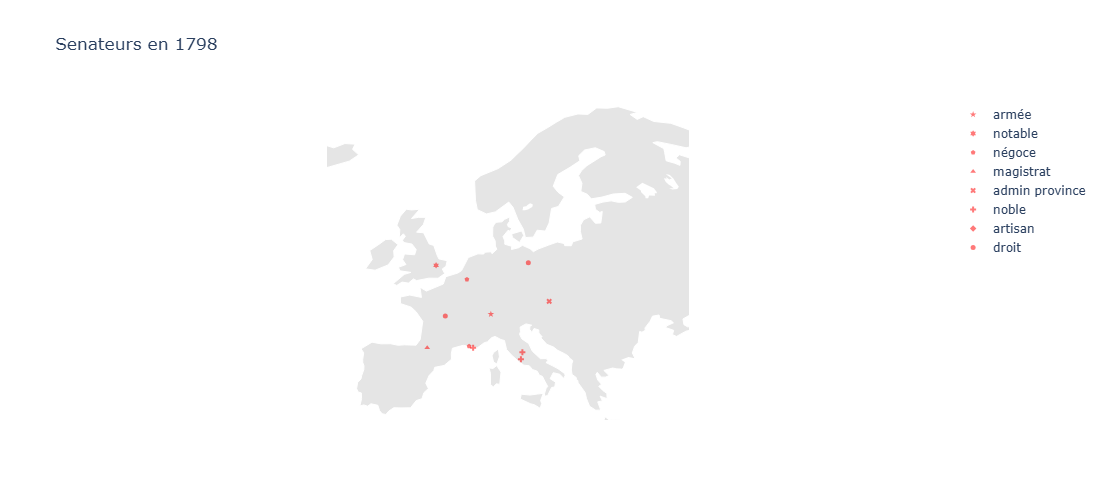

In [286]:
year = 1798
df = dic_annee[year]
df.head()
column_to_separe = 'en exercice'
column_to_separe2 = 'position_sociale'

#colors = ['rgb(239,243,255)','rgb(189,215,231)','rgb(107,174,214)','rgb(33,113,181)']
df = dic_annee[year]
fig = go.Figure()
i = 0
for value in df[column_to_separe].unique():
    if (value!= value):
        value = 'Inconnu'
    df_part = df[df[column_to_separe]==value]
    if column_to_separe2 is None:
        df_part["nombre_senateurs"] = df_part.groupby("nom_local").nom.transform("nunique")
        fig.add_trace(go.Scattergeo(
                lon = df_part['longitude'+str(year)],
                lat = df_part['latitude'+str(year)],
                text = df_part['nom_local'],
                fillcolor = colors[i],
                #opacity = 0.75,
                marker = dict(
                    size = df_part['nombre_senateurs']*5,
                    line_width = 0
                )))
    else:
        j=0
        for value2 in df[column_to_separe2].unique():
            df_part2 = df_part[df_part[column_to_separe2]==value2]
            df_part2["nombre_senateurs"] = df_part2.groupby("nom_local").nom.transform("nunique")
            if (not value2) or (value2!= value2):
                value2 = 'Inconnu'
            fig.add_trace(go.Scattergeo(
                    lon = df_part2['longitude'+str(year)],
                    lat = df_part2['latitude'+str(year)],
                    text = df_part2['nom_local'],
                    #fillcolor = 'red',
                    opacity = 0.75,
                
                    showlegend = True,
                    name = value2,
                    marker = dict(
                        size = df_part2['nombre_senateurs']*5,
                        line_width = 0,
                        symbol=markers[j],
                        color = colors[i],
                    )))
            j+=1
    i+=1
update_layout_default(fig, year = year)


In [202]:
### Préparer cas où personnes des deux types au même endroit

In [281]:
dic_annee[1798]

,nom_local1798,position_sociale,nom,annee nomin,latitude1798,longitude1798,en exercice,nom_local,nombre_senateurs
1,Berlin,droit,sieyes,1800.0,52.510885,13.398937,0,Berlin,1
14,"Cassel, Allemagne",NaN,hatry,1800.0,51.315783,9.497848,0,"Cassel, Allemagne",1
23,Égypte,artisan,monge,1800.0,26.254049,29.267547,0,Égypte,1
24,Toulon,noble,pleville-le-pelley,1800.0,43.125731,5.930492,0,Toulon,1
29,France,droit,volney,1800.0,46.603354,1.888334,0,France,1
30,Rome,noble,casabianca,1800.0,41.893320,12.482932,0,Rome,1
41,Vienne,admin province,françois de neufchateau,1800.0,48.208354,16.372504,0,Vienne,1
42,Lys,magistrat,herwyn,1800.0,43.130034,-0.352560,0,Lys,1
47,Marseille,négoce,lejeans,1800.0,43.296174,5.369953,0,Marseille,1
58,"Usa, Uk",notable,barthelemy,1800.0,52.215383,0.125833,0,"Usa, Uk",1


In [263]:
colors = ['red', 'blue', 'green', 'brown', 'purple', 'coral', 'orange',
            'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange',
            'darkorchid', 'darkred', 'darksalmon', 'darkseagreen',
            'darkslateblue', 'darkslategray',
            'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgrey', 'dodgerblue', 'firebrick',
            'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'gold', 'goldenrod', 'gray', 'grey']
markers = ['circle', 'square', 'diamond', 'cross', 'x', 'triangle-up', 'pentagon', 'hexagram',
           'star', 'hourglass', 'bowtie', 'asterisk', 'hash', 'y', 'triangle-down', 'octagon',]

In [287]:
import plotly.graph_objects as go

import pandas as pd
def plot_from_year(year = 1800, column_to_separe='en exercice', column_to_separe2=None, position = []):
    df = dic_annee[year]
    fig = go.Figure()
    i = 0
    for value in df[column_to_separe].unique():
        if (value!= value):
            value = 'Inconnu'
        df_part = df[df[column_to_separe]==value]
        if column_to_separe2 is None:
            df_part["nombre_senateurs"] = df_part.groupby("nom_local").nom.transform("nunique")
            fig.add_trace(go.Scattergeo(
                    lon = df_part['longitude'+str(year)],
                    lat = df_part['latitude'+str(year)],
                    text = df_part['nom_local'],
                    showlegend = True,
                    name = value,
                    #opacity = 0.75,
                    marker = dict(
                        size = df_part['nombre_senateurs']*5,
                        line_width = 0,
                        color = colors[i],
                    )))
        else:
            j=0
            for value2 in df[column_to_separe2].unique():
                if (value2!= value2):
                    value2 = 'Inconnu'
                df_part2 = df_part[df_part[column_to_separe2]==value2]
                df_part2["nombre_senateurs"] = df_part2.groupby("nom_local").nom.transform("nunique")
                fig.add_trace(go.Scattergeo(
                        lon = df_part2['longitude'+str(year)],
                        lat = df_part2['latitude'+str(year)],
                        text = df_part2['nom_local'],
                        opacity = 0.75,
                        showlegend = True,
                        name = value2,
                        marker = dict(
                            size = df_part2['nombre_senateurs']*5,
                            line_width = 0,
                            symbol=markers[j],
                            color = colors[i],
                        )))
                j+=1
        i+=1
    update_layout_default(fig, year = year)

    return fig

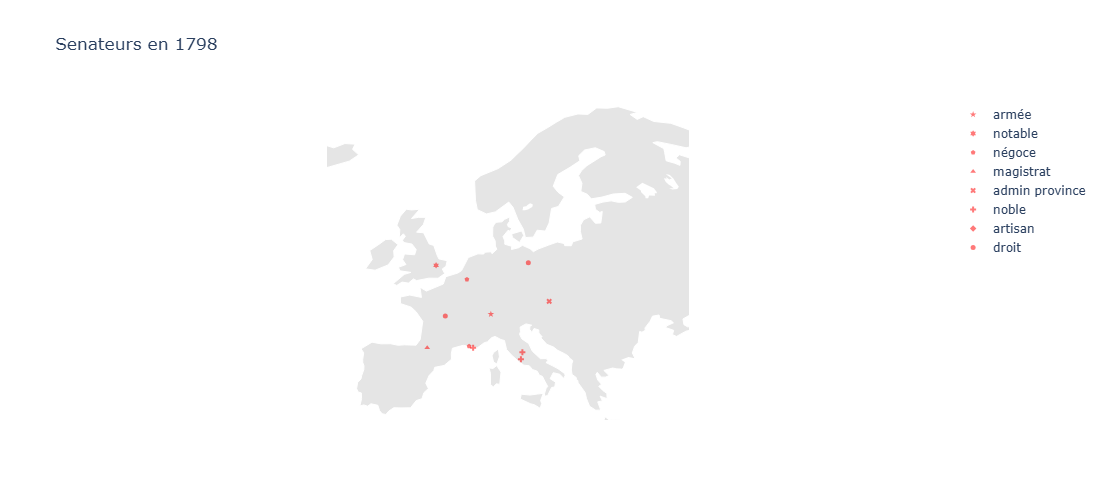

In [288]:
plot_from_year(1798, column_to_separe2 = 'position_sociale')

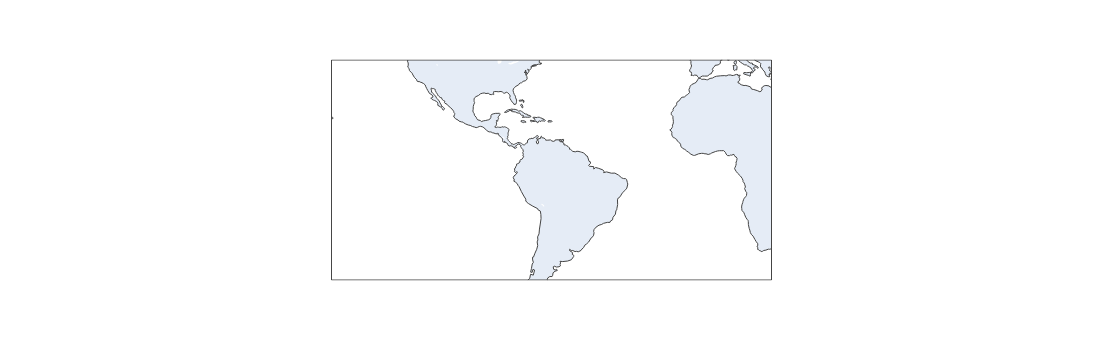

In [68]:
import plotly.express as px
import pyproj
df = dic_annee[1800]
df.to_crs(pyproj.CRS.from_epsg(4326), inplace=True)
fig = px.scatter_geo(df, geojson='geometry', color="en exercice",
                      size="nombre_senateurs")
fig.show()


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Initialize figure with subplots
def plot_several_year(years):
    cols, rows = 2,int(len(years)/2+0.5)
    fig = make_subplots(
        rows=rows, cols=cols, subplot_titles=(years)
    )

    # Add traces
    for annee i years:
        plot_from_year(
    
    # Update xaxis properties
    fig.update_xaxes(title_text="xaxis 1 title", row=1, col=1)
    fig.update_xaxes(title_text="xaxis 2 title", range=[10, 50], row=1, col=2)
    fig.update_xaxes(title_text="xaxis 3 title", showgrid=False, row=2, col=1)
    fig.update_xaxes(title_text="xaxis 4 title", type="log", row=2, col=2)
    
    # Update yaxis properties
    fig.update_yaxes(title_text="yaxis 1 title", row=1, col=1)
    fig.update_yaxes(title_text="yaxis 2 title", range=[40, 80], row=1, col=2)
    fig.update_yaxes(title_text="yaxis 3 title", showgrid=False, row=2, col=1)
    fig.update_yaxes(title_text="yaxis 4 title", row=2, col=2)
    
    # Update title and height
    fig.update_layout(title_text="Customizing Subplot Axes", height=700)
    
    fig.show()

In [25]:
years_consulat = list(range(1799, 1805))
def plot_several_years(years):
    cols, rows = 2,int(len(years)/2+0.5)  #num of subplots <= (cols x rows)
    # create figure with array of axes
    fig, axs = plt.subplots(nrows=rows, ncols=cols)
    fig.set_size_inches(6, 10)  #set it big enough for all subplots
    
    count = 0
    for irow in range(axs.shape[0]):
        for icol in range(axs.shape[1]):
            #print(icol, irow)
            if count<len(years):
                # plot that country on current axes
                gdf_country.plot(figsize=(20,15), color="gray", ax=axs[irow][icol])
                #dic_annee[years[count]][dic_annee[years[count]]["en exercice"]].plot(figsize=(20,15), ax=axs[irow][icol], color="yellow", aspect = 1, markersize = dic_annee[years[count]]["nombre_senateurs"]*20)
                #dic_annee[years[count]][~dic_annee[years[count]]["en exercice"]].plot(figsize=(20,15), ax=axs[irow][icol], color="green", aspect = 1, markersize = dic_annee[years[count]]["nombre_senateurs"]*20)
                dic_annee[years[count]].plot(column="en exercice", figsize=(20,15), ax=axs[irow][icol], aspect = 1, markersize = dic_annee[years[count]]["nombre_senateurs"]*20)
                #, column="en exercice"
                #senateurs["geometry"] = senateurs["coord"+str(years[count])]#[["coord"+str(years[count]), "nom_local"+str(years[count])]]
                #senateurs.plot(figsize=(20,15), ax=axs[irow][icol], color="yellow", aspect = 1)
                axs[irow][icol].set_xlim(minx, maxx)
                axs[irow][icol].set_ylim(miny, maxy)
                #world[ world['iso_a3'] == years[count] ].plot(ax=axs[irow][icol])
                axs[irow][icol].set_title('année : '+str(years[count]))
                count +=1
            else:
                # hide extra axes
                axs[irow][icol].set_visible(False)
    #plt.savefig("C:/Users/sylva/OneDrive/Bureau/senat/plot/map_year")
    plt.show()

TypeError: Cannot cast array data from dtype('float64') to dtype('int64') according to the rule 'safe'

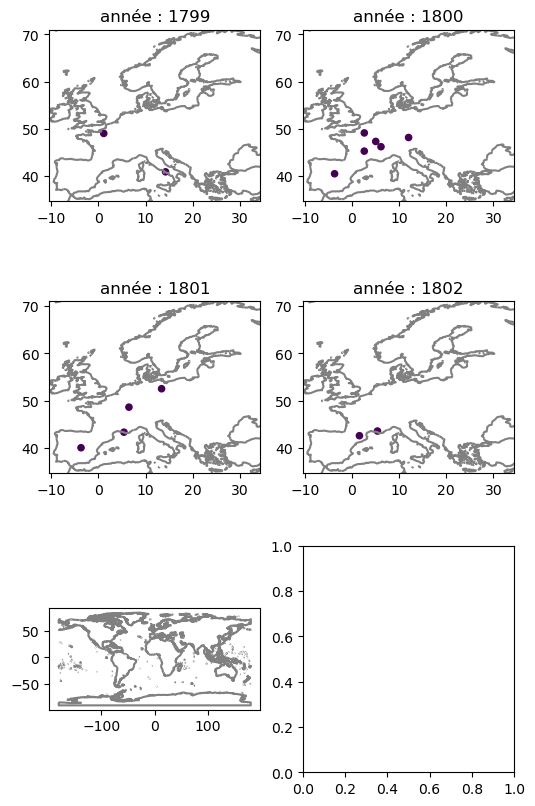

In [37]:
plot_several_years(years_consulat)

C:\Users\sylva\AppData\Local\Temp\ipykernel_5992\429922821.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dic_annee[years[count]].plot(column="en exercice", figsize=(20,15), ax=axs[irow][icol], aspect = 1, markersize = dic_annee[years[count]]["nombre_senateurs"]*20)
C:\Users\sylva\AppData\Local\Temp\ipykernel_5992\429922821.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dic_annee[years[count]].plot(column="en exercice", figsize=(20,15), ax=axs[irow][icol], aspect = 1, markersize = dic_annee[years[count]]["nombre_senateurs"]*20)


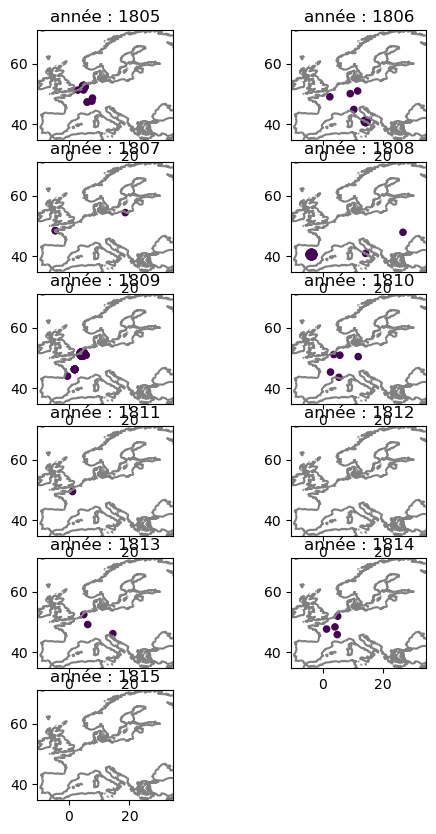

In [38]:
years_empire = list(range(1805, 1816))
plot_several_years(years_empire)

In [ ]:
dic_annee[years[1]]

IndexError: tuple index out of range

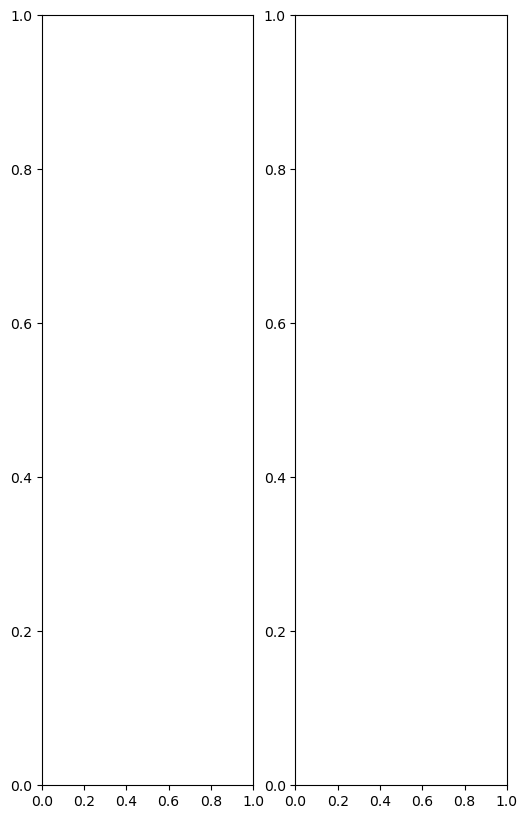

In [39]:
years_emp = list(range(1805, 1806))
plot_several_years(years_emp)

In [ ]:
#for annee in years:
#    senateurs_en_exercice = senateurs

In [67]:
years_revolution = list(range(1790, 1788))
plot_several_years(years_revolution)

ValueError: Number of rows must be a positive integer, not 0

<Figure size 640x480 with 0 Axes>

In [ ]:
senateurs.columns

In [ ]:
dic_annee[1799].columns

In [ ]:
liste_futur


In [ ]:
"""distance_moyenne_exercice = {}
part_voyage_exercice = {}
distance_moyenne_futur = {}
part_voyage_futur = {}
for annee in years:
    senateurs_en_exercice = senateurs[senateurs["annee nomin"]<=annee]
    futurs_senateurs = senateurs[senateurs["annee nomin"]>annee]
    liste_exercice = pd.merge(senateurs_en_exercice, dic_annee[annee], on = "nom", how = 'left')["distance"]
    if len(senateurs_en_exercice)>0:
        part_voyage_exercice[annee] = sum(liste_exercice.notna())/len(senateurs_en_exercice)
        distance_moyenne_exercice[annee] = np.mean(liste_exercice)
    liste_futur = pd.merge(futurs_senateurs, dic_annee[annee], on = "nom", how = 'left')["distance"]
    if len(futurs_senateurs)>0:
        part_voyage_futur[annee] = sum(liste_futur.notna())/len(futurs_senateurs)
        distance_moyenne_futur[annee] = np.mean(liste_futur)"""

In [73]:
distance_moyenne = pd.DataFrame(columns = ["year", "en exercice", "distance moyenne"])
part_voyage = pd.DataFrame(columns = ["year", "en exercice", "part en déplacement"])
for annee in years:
    senateurs_en_exercice = senateurs[senateurs["annee nomin"]<=annee]
    futurs_senateurs = senateurs[senateurs["annee nomin"]>annee]
    liste_exercice = pd.merge(senateurs_en_exercice, dic_annee[annee], on = "nom", how = 'left')["distance"]
    if len(senateurs_en_exercice)>0:
        value = sum(liste_exercice.notna())/len(senateurs_en_exercice)
        dic_line = {"year" : annee, "en exercice": "en exercice", "part en déplacement": value}
        part_voyage = pd.concat([part_voyage, pd.DataFrame({k:[v] for k,v in dic_line.items()})])
        dic_line = {"year" : annee, "en exercice": "en exercice", "distance moyenne": np.mean(liste_exercice)}
        distance_moyenne = pd.concat([distance_moyenne, pd.DataFrame({k:[v] for k,v in dic_line.items()})]) 
    liste_futur = pd.merge(futurs_senateurs, dic_annee[annee], on = "nom", how = 'left')["distance"]
    if len(futurs_senateurs)>0:
        value = sum(liste_futur.notna())/len(futurs_senateurs)
        dic_line = {"year" : annee, "en exercice": "pas en exercice", "part en déplacement": value}
        part_voyage = pd.concat([part_voyage, pd.DataFrame({k:[v] for k,v in dic_line.items()})])
        dic_line = {"year" : annee, "en exercice": "pas en exercice", "distance moyenne": np.mean(liste_futur)}
        distance_moyenne = pd.concat([distance_moyenne, pd.DataFrame({k:[v] for k,v in dic_line.items()})]) 

C:\Users\sylva\AppData\Local\Temp\ipykernel_12728\3135249004.py:17: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sylva\AppData\Local\Temp\ipykernel_12728\3135249004.py:19: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [74]:
import plotly.express as px

"""px.line(x = part_voyage_futur.keys(), y = part_voyage_futur.values(), title = "Part des futurs sénateurs avec un voyage recensé")
px.line(x = part_voyage_exercice.keys(), y = part_voyage_exercice.values(), title = "Part des sénateurs en cours avec un voyage recensé")"""

'px.line(x = part_voyage_futur.keys(), y = part_voyage_futur.values(), title = "Part des futurs sénateurs avec un voyage recensé")\npx.line(x = part_voyage_exercice.keys(), y = part_voyage_exercice.values(), title = "Part des sénateurs en cours avec un voyage recensé")'

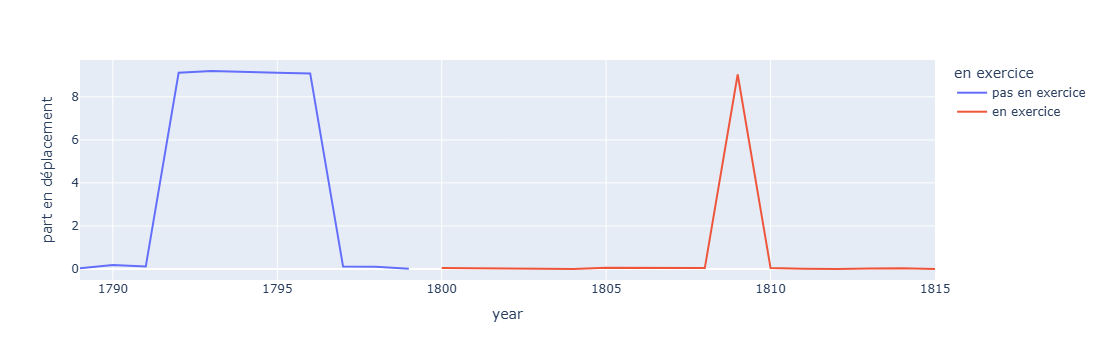

In [75]:
px.line(part_voyage, x= "year", y = "part en déplacement", color = 'en exercice')

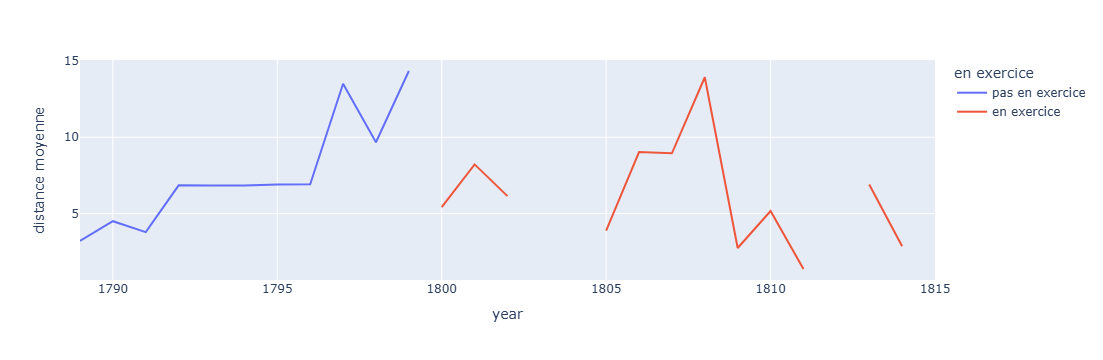

In [76]:
px.line(distance_moyenne, x= "year", y = "distance moyenne", color = 'en exercice')

In [77]:
# Regarder les âges moyens à la nomination, la répartition des types... des nouveaux sénateurs par an

In [78]:
# régresser la distance sur le fait d'être nommé avec effet fixe individu ?

In [79]:
# proche d'un endroit où la personne était déjà allé auparavant ? 
#-> récupérer l'endroit précédent le plus proche, rapport de distance >90%

In [80]:
age_moyen_nouveau = {}
for annee in years:
    age_moyen_nouveau[annee] = annee - np.mean(senateurs[senateurs["annee nomin"]==annee]["annee naiss"])

In [81]:
age_moyen_nouveau

{1789: nan,
 1790: nan,
 1791: nan,
 1792: nan,
 1793: nan,
 1794: nan,
 1795: nan,
 1796: nan,
 1797: nan,
 1798: nan,
 1799: nan,
 1800: 100.0,
 1801: nan,
 1802: nan,
 1803: nan,
 1804: nan,
 1805: nan,
 1806: nan,
 1807: nan,
 1808: nan,
 1809: nan,
 1810: nan,
 1811: nan,
 1812: nan,
 1813: nan,
 1814: nan,
 1815: nan}

In [ ]:
px.line(x = age_moyen_nouveau.keys(), y = age_moyen_nouveau.values())

In [ ]:
import bs4
import pandas as pd
from urllib import request
import re
import geopandas as gpd
import networkx as nx
import numpy as np
from mpl_toolkits.basemap import Basemap as Basemap
from pycountry_convert import country_alpha2_to_continent_code, country_name_to_country_alpha2
import geopy
from geopy.geocoders import Nominatim
from matplotlib import pyplot as plt
from ast import literal_eval
import plotly.graph_objs as go
import plotly.express as px
import math



def graph_era(b,e):
    '''
    Tracer le graphique des proportions de mathématiciens par pays entre deux dates
    '''
    #à l'aide de is_alive, on récupère les pays des mathématiciens vivants entre deux dates
    active = df_math_doc.loc[df_math_doc.index.to_series().apply(lambda name : is_alive(b,e,name))==True,
                    ['Country of citizenship']] 
    
    #on crée un dictionnaire qui recense les pays et le nombre de mathématicien qui y a travaillé sur la période
    d_cntry = {}
    for countries in active['Country of citizenship'].values:
        for country in countries:
            count = d_cntry.get(country,0) #on obtient le nombre de mathématiciens pour ce pays ou on crée une nouvelle entrée
            d_cntry[country] = count + 1 #on ajoute le nouveau mathématicien
    df_countries = pd.DataFrame(d_cntry.values(),index=d_cntry.keys(),columns=['Number of mathematicians'])
    df_countries = df_countries.reset_index().rename(columns={'index':'Country'})
    
    #on crée freq pour obtenir des fréquences au lieu des nombres, pour pouvoir faire des comparaisons
    #df_countries['Freq of mathematicians'] = df_countries['Number of mathematicians']/df_countries['Number of mathematicians'].sum()
    df_countries['log # of mathematicians'] = df_countries['Number of mathematicians'].apply(lambda x : math.log(1+x))
    #on veut à présent construire une carte
    #pour cela, on crée un geodataframe
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world=world[['name','geometry']] #récupération des seules colonnes intéressantes
    world = world.rename(columns={'name':'Country'})
    
    df_countries = world.merge(df_countries,on='Country')
    
    #on trace la carte
    fig = px.choropleth(df_countries,
             geojson = df_countries.geometry,
             locations="Country", 
             locationmode = 'country names',
             color= 'log # of mathematicians',
            #color = 'Freq of mathematicians',
             color_continuous_scale =px.colors.sequential.Sunsetdark,
             #range_color=[0,1],
             hover_name = "Country",
             title='<br>Countries of work of mathematicians from %s to %s'%(b,e))
    return fig,df_countries
    